In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#OHLCV
candle = {

          "open": 100.00,
          "high": 108.00,
          "low":  97.00,
          "close": 105.00,
          "volume": 15230
}

candle

{'open': 100.0, 'high': 108.0, 'low': 97.0, 'close': 105.0, 'volume': 15230}

In [4]:
def analyze_candle(candle):
   #Take a candle and return its anatomy as a new dict.
   o = candle['open']
   h = candle['high']
   l = candle['low']
   c = candle['close']
   v = candle['volume']

   is_bullish = c > o

   body = abs(c-o)

   # The top of the body is whichever open/close is higher.
   body_top = max(o, c)
   # The bottom of the body is whichever open/close is lower.
   body_bottom = min(o, c)

   upper_wick = h - body_top
   lower_wick = body_bottom - l

   range = h - l

   return {
       "is_bullish": is_bullish,
       "body": body,
       "upper_wick": upper_wick,
       "lower_wick": lower_wick,
       "range": range
   }

analyze_candle(candle)

{'is_bullish': True,
 'body': 5.0,
 'upper_wick': 3.0,
 'lower_wick': 3.0,
 'range': 11.0}

In [6]:
result = analyze_candle(candle)

direction = "BULLISH (buyers won)" if result["is_bullish"] else "BEARISH (seller won)"

print(f"Direction:    {direction}")
print(f"Body size:    {result['body']}")
print(f"Upper wick:   {result['upper_wick']}")
print(f"Lower wick:   {result['lower_wick']}")
print(f"Total range:  {result['range']}")

Direction:    BULLISH (buyers won)
Body size:    5.0
Upper wick:   3.0
Lower wick:   3.0
Total range:  11.0


In [8]:
candles = [
    {"open":100.00, "high":103.00, "low":99.00, "close":102.50, "volume":12000},
    {"open":102.50, "high":102.80, "low":100.10, "close":100.40, "volume":9800},
    {"open":100.40, "high":100.60, "low":96.00, "close":99.90, "volume":21000},
    {"open":99.90, "high":104.00, "low":99.70, "close":103.80, "volume":17500},
    {"open":103.80, "high":106.00, "low":103.50, "close":105.90, "volume":14200}
]

for i, c in enumerate(candles):
  stats=analyze_candle(c)
  direction = "Bullish" if stats["is_bullish"] else "Bearish"
  print(
      f"Candle {i}: {direction:8s} | "
      f"body={stats['body']: .2f} "
      f"upper_wick={stats['upper_wick']: .2f} "
      f"lower_wick={stats['lower_wick']: .2f} "
      f"range={stats['range']: .2f}"
  )

Candle 0: Bullish  | body= 2.50 upper_wick= 0.50 lower_wick= 1.00 range= 4.00
Candle 1: Bearish  | body= 2.10 upper_wick= 0.30 lower_wick= 0.30 range= 2.70
Candle 2: Bearish  | body= 0.50 upper_wick= 0.20 lower_wick= 3.90 range= 4.60
Candle 3: Bullish  | body= 3.90 upper_wick= 0.20 lower_wick= 0.20 range= 4.30
Candle 4: Bullish  | body= 2.10 upper_wick= 0.10 lower_wick= 0.30 range= 2.50


In [9]:
bullish_count = sum(1 for c in candles if analyze_candle(c)["is_bullish"])
bearish_count = len(candles) - bullish_count

print(f"Bullish Candles: {bullish_count}")
print(f"Bearish Candles: {bearish_count}")

avg_body = sum(analyze_candle(c)["body"] for c in candles) / len(candles)
print(f"Average body size: {avg_body: .2f}")

Bullish Candles: 3
Bearish Candles: 2
Average body size:  2.22


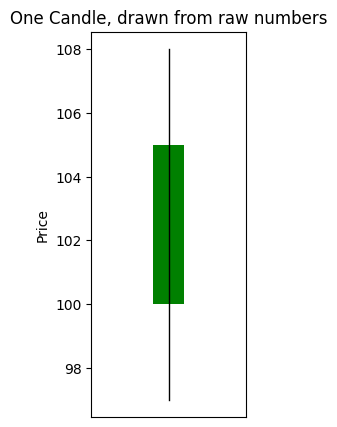

In [10]:
import matplotlib.pyplot as plt

def sketch_candle(candle):
  o = candle['open']
  h = candle['high']
  l = candle['low']
  c = candle['close']

  is_bullish = c > o
  color = "green" if is_bullish else "red"

  body_top = max(o, c)
  body_bottom = min(o, c)

  fig, ax = plt.subplots(figsize=(2,5))

  #wick: thin vertical line
  ax.plot([0, 0],[l, h], color="black", linewidth=1)

  #body : rectangle
  ax.bar(0, body_top - body_bottom, bottom=body_bottom, width=0.4, color= color)

  ax.set_xlim(-1,1)
  ax.set_xticks([])
  ax.set_title("One Candle, drawn from raw numbers")
  ax.set_ylabel("Price")

  plt.show()

sketch_candle(candle)